# Probing Explorer

Interactive notebook for the Neural NLI probing framework.

**Sections:**
1. **Single pair** — run inference on a `(target_text, hypothesis)` pair you type in
2. **Interactive widget** — same with live text boxes (requires `ipywidgets`)
3. **SPR entry explorer** — all 18 proto-role predictions for a given SPR ID
4. **Corpus statistics** — distributions and per-property summaries from `predictions.jsonl`


In [27]:
import sys
from pathlib import Path

_root = Path('.').resolve().parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

MODEL_NAME       = 'roberta-large-mnli'
PREDICTIONS_FILE = _root / 'data' / 'processed' / 'predictions.jsonl'
DEVICE           = 'auto'
THRESHOLD        = 0.5

In [28]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from probing import Prober

prober = Prober(MODEL_NAME, device=DEVICE, threshold=THRESHOLD)
print(f'Loaded  : {MODEL_NAME}')
print(f'Classes : {prober.label_mapper.n_classes}')
print(f'Device  : {prober.device}')

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-large-mnli
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded  : roberta-large-mnli
Classes : 3
Device  : cuda


## 1. Single Pair

Edit `target_text` and `hypothesis` in the cell below, then run it.

In [29]:
target_text = '[ARG] John [/ARG] opened [PRED] the door [/PRED].'
hypothesis  = 'John caused the door to open.'

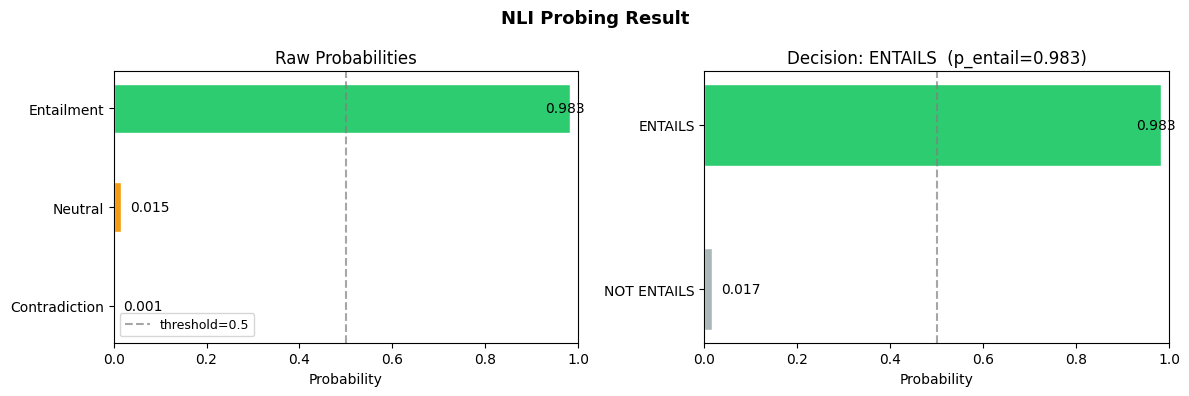

Target : [ARG] John [/ARG] opened [PRED] the door [/PRED].
Hypo   : John caused the door to open.
Result : ENTAILS  (p_entail=0.9831)
{'id': 'b3994c51ad792e8e', 'p_entail': 0.98312563, 'p_not_entail': 0.01687435, 'pred_bool': True, 'pred_label': 'ENTAILS', 'p_entailment': 0.98312563, 'p_neutral': 0.01548674, 'p_contradiction': 0.0013876, 'target_text': '[ARG] John [/ARG] opened [PRED] the door [/PRED].', 'hypothesis': 'John caused the door to open.'}


In [30]:
def plot_result(result):
    """Visualise a single inference result (also used by the widget below)."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('NLI Probing Result', fontsize=13, fontweight='bold')

    if prober.label_mapper.n_classes == 3:
        raw_labels = ['Contradiction', 'Neutral', 'Entailment']
        raw_values = [result['p_contradiction'], result['p_neutral'],
                      result['p_entailment']]
        raw_colors = ['#e74c3c', '#f39c12', '#2ecc71']
    else:
        raw_labels = ['Not entailment', 'Entailment']
        raw_values = [result['p_not_entailment'], result['p_entailment']]
        raw_colors = ['#e74c3c', '#2ecc71']

    bars = ax1.barh(raw_labels, raw_values, color=raw_colors,
                    edgecolor='white', height=0.5)
    ax1.axvline(THRESHOLD, color='gray', linestyle='--', alpha=0.7,
                label=f'threshold={THRESHOLD}')
    ax1.set_xlim(0, 1)
    ax1.set_xlabel('Probability')
    ax1.set_title('Raw Probabilities')
    ax1.legend(fontsize=9)
    for b, v in zip(bars, raw_values):
        ax1.text(min(v + 0.02, 0.93), b.get_y() + b.get_height() / 2,
                 f'{v:.3f}', va='center', fontsize=10)

    b_vals   = [result['p_not_entail'], result['p_entail']]
    b_labels = ['NOT ENTAILS', 'ENTAILS']
    decided  = result['pred_bool']
    b_colors = ['#aab7b8', '#aab7b8']
    b_colors[1 if decided else 0] = '#2ecc71' if decided else '#e74c3c'

    bars2 = ax2.barh(b_labels, b_vals, color=b_colors, edgecolor='white', height=0.5)
    ax2.axvline(THRESHOLD, color='gray', linestyle='--', alpha=0.7)
    ax2.set_xlim(0, 1)
    ax2.set_xlabel('Probability')
    ax2.set_title(
        f"Decision: {result['pred_label']}  (p_entail={result['p_entail']:.3f})"
    )
    for b, v in zip(bars2, b_vals):
        ax2.text(min(v + 0.02, 0.93), b.get_y() + b.get_height() / 2,
                 f'{v:.3f}', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    print(f"Target : {result.get('target_text', '')}")
    print(f"Hypo   : {result.get('hypothesis', '')}")
    print(f"Result : {result['pred_label']}  (p_entail={result['p_entail']:.4f})")

    print(result)


result = prober.predict_one(target_text, hypothesis, return_inputs=True)
plot_result(result)

## 2. Interactive Example

In [31]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    _layout = widgets.Layout(width='95%', height='56px')
    _style  = {'description_width': '60px'}
    ta_target = widgets.Textarea(
        value='[ARG] John [/ARG] opened [PRED] the door [/PRED].',
        description='Target:', layout=_layout, style=_style,
    )
    ta_hypo = widgets.Textarea(
        value='John caused the door to open.',
        description='Hypo:', layout=_layout, style=_style,
    )
    btn = widgets.Button(description='Run inference',
                         button_style='primary', icon='play')
    out = widgets.Output()

    def _run(_):
        with out:
            clear_output(wait=True)
            r = prober.predict_one(ta_target.value, ta_hypo.value,
                                   return_inputs=True)
            plot_result(r)

    btn.on_click(_run)
    display(widgets.VBox([ta_target, ta_hypo, btn, out]))

except ImportError:
    print('ipywidgets not found.  Run:  pip install ipywidgets')

## 3. Explorer

Set `spr_id` to any key from `spr1.json`

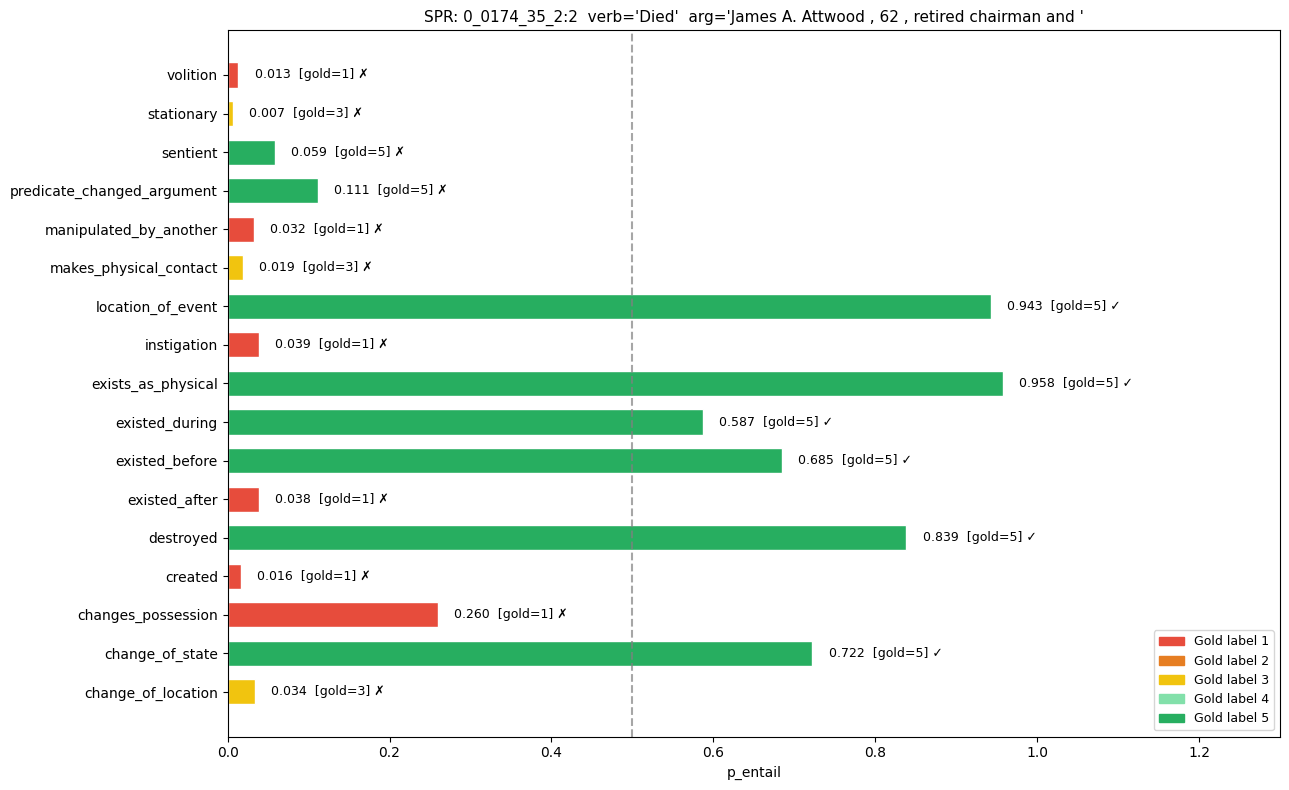

,property,p_entail,p_not_entail,pred_label,label,applicable
0,change_of_location,0.034300,0.965700,NOT_ENTAILS,3,True
1,change_of_state,0.722400,0.277600,ENTAILS,5,True
2,changes_possession,0.260000,0.740000,NOT_ENTAILS,1,False
3,created,0.016300,0.983700,NOT_ENTAILS,1,True
4,destroyed,0.838600,0.161400,ENTAILS,5,True
5,existed_after,0.038300,0.961700,NOT_ENTAILS,1,True
6,existed_before,0.684900,0.315100,ENTAILS,5,True
7,existed_during,0.586700,0.413300,ENTAILS,5,True
8,exists_as_physical,0.957700,0.042300,ENTAILS,5,True
9,instigation,0.038700,0.961300,NOT_ENTAILS,1,False


In [32]:
spr_id = '0_0174_35_2:2' 

rows = []
with open(PREDICTIONS_FILE) as f:
    for line in f:
        r = json.loads(line)
        if r.get('spr_id') == spr_id:
            rows.append(r)

if not rows:
    print(f"SPR ID '{spr_id}' not found in {PREDICTIONS_FILE}")
else:
    df = pd.DataFrame(rows).sort_values('property').reset_index(drop=True)

    LABEL_COLORS = {1: '#e74c3c', 2: '#e67e22', 3: '#f1c40f',
                    4: '#82e0aa', 5: '#27ae60'}
    bar_colors = [LABEL_COLORS.get(int(r.label), '#95a5a6')
                  for r in df.itertuples()]

    fig, ax = plt.subplots(figsize=(13, 8))
    y = range(len(df))
    ax.barh(list(y), df['p_entail'].tolist(),
            color=bar_colors, edgecolor='white', height=0.65)
    ax.axvline(THRESHOLD, color='gray', linestyle='--', alpha=0.7,
               label=f'threshold={THRESHOLD}')
    ax.set_yticks(list(y))
    ax.set_yticklabels(df['property'].tolist())
    ax.set_xlim(0, 1.3)
    ax.set_xlabel('p_entail')
    ax.set_title(
        f"SPR: {spr_id}  verb={df.iloc[0]['verb']!r}"
        f"  arg={df.iloc[0]['arg'][:45]!r}",
        fontsize=11,
    )

    for i, row in enumerate(df.itertuples()):
        sym = chr(10003) if row.pred_bool else chr(10007)
        ax.text(row.p_entail + 0.01, i,
                f'  {row.p_entail:.3f}  [gold={row.label}] {sym}',
                va='center', fontsize=9)

    ax.legend(
        handles=[mpatches.Patch(color=c, label=f'Gold label {l}')
                 for l, c in LABEL_COLORS.items()],
        loc='lower right', fontsize=9,
    )
    plt.tight_layout()
    plt.show()

    from IPython.display import display
    tbl = df[['property', 'p_entail', 'p_not_entail',
              'pred_label', 'label', 'applicable']].copy()
    tbl['p_entail']     = tbl['p_entail'].round(4)
    tbl['p_not_entail'] = tbl['p_not_entail'].round(4)
    display(
        tbl.style
           .background_gradient(subset=['p_entail'], cmap='RdYlGn')
           .background_gradient(subset=['label'],   cmap='RdYlGn')
    )

## 4. Statistics

In [33]:
print('Loading predictions …')
records = []
with open(PREDICTIONS_FILE) as f:
    for line in f:
        records.append(json.loads(line))
df_all = pd.DataFrame(records)
n_entries = df_all['spr_id'].nunique()
splits    = df_all['split'].value_counts().to_dict()
print(f'Loaded {len(df_all):,} records | {n_entries:,} SPR entries | splits: {splits}')

Loading predictions …
Loaded 4,383 records | 244 SPR entries | splits: {'train': 4265, 'dev': 64, 'test': 54}


/tmp/ipykernel_437417/2101659180.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(label_groups, labels=[1, 2, 3, 4, 5], patch_artist=True)


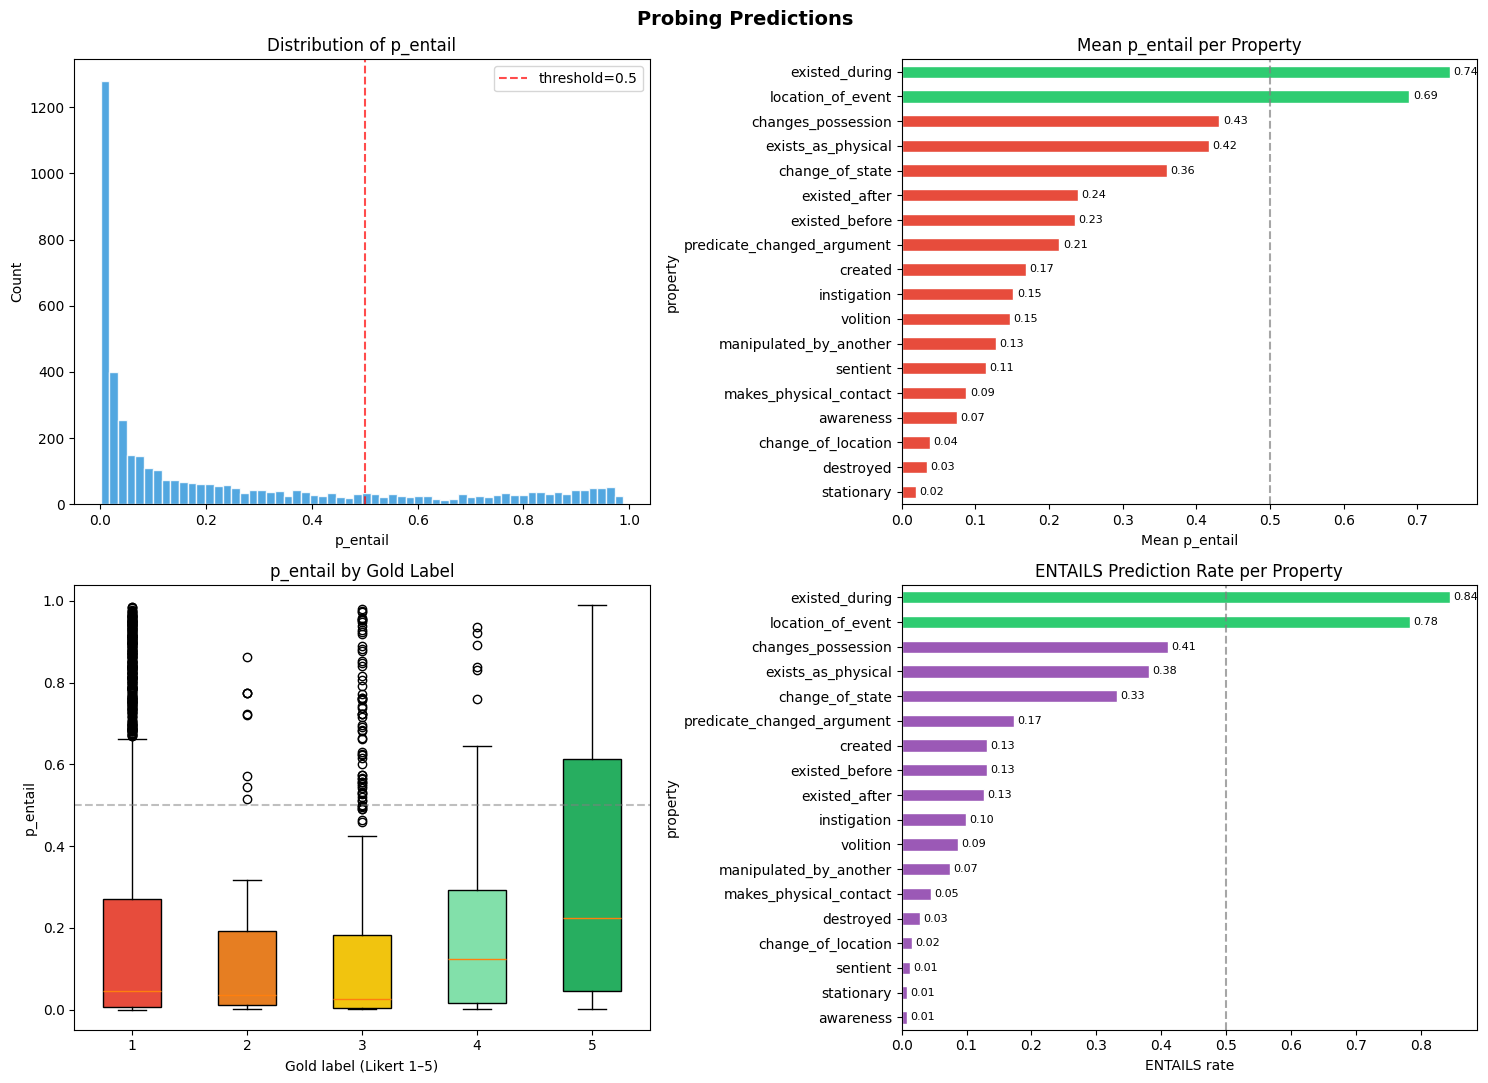

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Probing Predictions',
             fontsize=14, fontweight='bold')

ax = axes[0, 0]
ax.hist(df_all['p_entail'], bins=60, color='#3498db', edgecolor='white', alpha=0.85)
ax.axvline(0.5, color='red', linestyle='--', alpha=0.7, label='threshold=0.5')
ax.set_xlabel('p_entail')
ax.set_ylabel('Count')
ax.set_title('Distribution of p_entail')
ax.legend()

ax = axes[0, 1]
means = df_all.groupby('property')['p_entail'].mean().sort_values()
bar_c = ['#2ecc71' if v >= 0.5 else '#e74c3c' for v in means]
means.plot.barh(ax=ax, color=bar_c, edgecolor='white')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.7)
ax.set_xlabel('Mean p_entail')
ax.set_title('Mean p_entail per Property')
for i, v in enumerate(means):
    ax.text(v + 0.005, i, f'{v:.2f}', va='center', fontsize=8)

ax = axes[1, 0]
label_groups = [
    df_all[df_all['label'] == lv]['p_entail'].values for lv in range(1, 6)
]
bp = ax.boxplot(label_groups, labels=[1, 2, 3, 4, 5], patch_artist=True)
for patch, color in zip(bp['boxes'],
                        ['#e74c3c', '#e67e22', '#f1c40f', '#82e0aa', '#27ae60']):
    patch.set_facecolor(color)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Gold label (Likert 1–5)')
ax.set_ylabel('p_entail')
ax.set_title('p_entail by Gold Label')

ax = axes[1, 1]
rates = df_all.groupby('property')['pred_bool'].mean().sort_values()
bar_c2 = ['#2ecc71' if v >= 0.5 else '#9b59b6' for v in rates]
rates.plot.barh(ax=ax, color=bar_c2, edgecolor='white')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.7)
ax.set_xlabel('ENTAILS rate')
ax.set_title('ENTAILS Prediction Rate per Property')
for i, v in enumerate(rates):
    ax.text(v + 0.005, i, f'{v:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()